<div style="background:linear-gradient(135deg,#7c2d12 0%,#c2410c 55%,#fb923c 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fed7aa;font-weight:700;text-transform:uppercase">Chapter 186 &middot; Capstone 25 &middot; Multiple Regression</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">A Pay Equity Review</div>
  <div style="font-size:15px;color:#fed7aa;max-width:820px;line-height:1.6">The raw gap is 14.4 percent. Add every control and it is 2.3. Both numbers are correct, they answer different questions, and the control that does most of the work is the one that should not be added without an argument.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm, statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from scipy import stats
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
OR, DK, LT, MUT, GD = "#c2410c", "#7c2d12", "#fb923c", "#94a3b8", "#047857"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-pay-equity-review.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
raw   = load("Employees")
plan  = load("AnalysisPlan")
truth = load("truth")
print("rows in the HRIS export:", f"{len(raw):,}")
raw.head()

rows in the HRIS export: 3,648


,employee_id,gender,age,years_experience,education,department,job_level,performance_rating,annual_salary
0,P50533,Male,30,6.3,Bachelor,Operations,3,4.0,81300
1,P51771,Male,27,6.7,Master or above,Operations,4,3.0,86900
2,P50692,Female,38,14.6,Bachelor,Customer Support,3,3.0,83500
3,P52284,Female,24,4.6,Bachelor,Engineering,4,5.0,99200
4,P52869,Male,39,8.4,Master or above,Sales,3,3.0,83600


## Step 1 &middot; The plan, and the fact that there are two questions

The single most common failure in a pay equity review is producing one number. There are two, they mean different things, and a report that gives only one of them is answering a question nobody asked.

In [2]:
for line in plan.analysis_plan.fillna(""):
    print(line)

AGREED WITH LEGAL AND HR BEFORE THE SALARY FILE WAS OPENED.

Q1 THE UNADJUSTED QUESTION: what is the difference in average pay between women and men
   across the whole company? This is the number that describes the workforce as it is.
Q2 THE ADJUSTED QUESTION: among people doing similar work with similar backgrounds, what is
   the difference in pay? This is the number that speaks to how individuals are paid.
   THESE ARE DIFFERENT QUESTIONS. Both get reported. Neither is 'the' pay gap.

M1 OUTCOME: log of annual salary, so coefficients read as approximate percentage differences.
M2 CONTROLS, in a stated order so each step is visible: experience, education, department,
   performance rating, and then job level LAST and separately, for the reason in M3.
M3 JOB LEVEL IS NOT AN ORDINARY CONTROL. If women are promoted more slowly than their
   experience and performance warrant, then job level is partly a RESULT of unequal treatment.
   Controlling for it measures the gap WITHIN levels an

**Read M3.** Job level is not an ordinary control variable. It is assigned by the company, which means it can carry the very unfairness the review is looking for. Every other decision in this notebook follows from taking that seriously.

## Step 2 &middot; Cleaning

In [3]:
d = raw.drop_duplicates(subset="employee_id").copy()
print(f"raw rows                    {len(raw):,}")
print(f"after the duplicate export  {len(d):,}")

d["department"] = d.department.str.title().str.strip()
d = d[d.annual_salary > 0]
print(f"after voiding zero salaries {len(d):,}   (payroll errors, not salaries)")

d.loc[d.years_experience == -1, "years_experience"] = np.nan
d = d.dropna(subset=["years_experience"])
print(f"after experience sentinels  {len(d):,}")

d["perf_missing"] = d.performance_rating.isna().astype(int)
d["perf"] = d.performance_rating.fillna(d.performance_rating.median())
print(f"\nmissing performance ratings {d.perf_missing.sum()}  kept, with an explicit indicator")

d["logpay"] = np.log(d.annual_salary)
d["female"] = (d.gender == "Female").astype(int)
d["edu_i"] = d.education.map({"High school": 0, "Bachelor": 1, "Master or above": 2})
print(f"\nanalysis file               {len(d):,}   women {d.female.mean():.1%}")

raw rows                    3,648
after the duplicate export  3,600
after voiding zero salaries 3,591   (payroll errors, not salaries)
after experience sentinels  3,569

missing performance ratings 69  kept, with an explicit indicator

analysis file               3,569   women 47.1%


**Missing performance ratings get an indicator, not a deletion.** Dropping the 69 people without a review would silently change who the study is about. Filling with the median and flagging that it was filled keeps them in and keeps the fill visible to the model.

## Step 3 &middot; First look

Everything below is fitted on log pay rather than pay. That is a modeling decision made in the first line of the next step, and it deserves a look rather than an assertion.

In [4]:
print(f"{len(d):,} employees, {d.female.mean():.1%} women")
print(f"  annual salary   median {d.annual_salary.median():,.0f}   "
      f"quartiles {d.annual_salary.quantile(.25):,.0f} to {d.annual_salary.quantile(.75):,.0f}")
print(f"  shape           skew {d.annual_salary.skew():+.2f} as paid, "
      f"{d.logpay.skew():+.2f} logged   "
      f"(kurtosis {d.annual_salary.kurtosis():+.2f} to {d.logpay.kurtosis():+.2f})")
print( "                  which is why every model below is fitted on log pay, where a "
       "coefficient reads as a percentage")
print(f"  women           median pay {d.loc[d.female == 1, 'annual_salary'].median():,.0f}, "
      f"median experience {d.loc[d.female == 1, 'years_experience'].median():.1f} years")
print(f"  men             median pay {d.loc[d.female == 0, 'annual_salary'].median():,.0f}, "
      f"median experience {d.loc[d.female == 0, 'years_experience'].median():.1f} years")

3,569 employees, 47.1% women
  annual salary   median 82,000   quartiles 65,900 to 105,100
  shape           skew +1.17 as paid, +0.32 logged   (kurtosis +1.58 to -0.32)
                  which is why every model below is fitted on log pay, where a coefficient reads as a percentage
  women           median pay 75,300, median experience 6.8 years
  men             median pay 88,800, median experience 8.5 years


**What this shows.** Pay is right-skewed, as pay almost always is, and logging it removes most of that. That matters for the regression to come, because ordinary least squares fitted to a long-tailed outcome lets the highest paid handful of people pull the line around.

The group summary is the plain fact the review starts from. Women in this file have a lower median salary and fewer years of experience than men. Both of those are true at the same time, and separating them is the entire job of the specification ladder in Step 5.

/var/folders/wv/rntn6xtd407cmdsyx0b0wwnw0000gn/T/ipykernel_33248/1955549404.py:48: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, tick_labels=["men", "women"], patch_artist=True, widths=0.5,


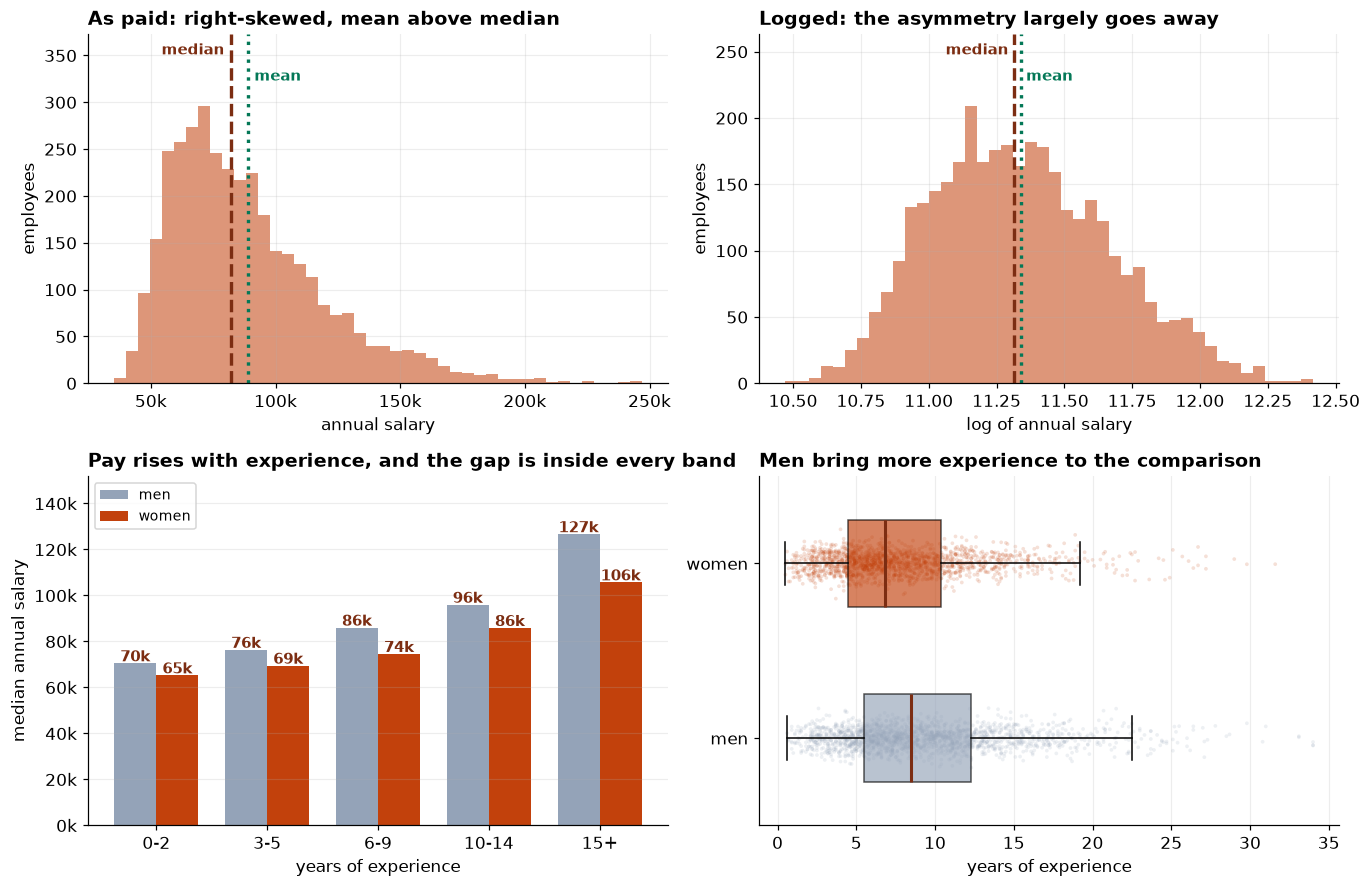

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12.6, 8.2))

ax = axes[0, 0]
ax.hist(d.annual_salary, bins=44, color=OR, alpha=0.55)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
ax.axvline(d.annual_salary.median(), color=DK, lw=2.2, ls="--")
ax.axvline(d.annual_salary.mean(), color=GD, lw=2.2, ls=":")
top = ax.get_ylim()[1]; ax.set_ylim(0, top*1.20)
ax.text(d.annual_salary.median()*0.97, top*1.13, "median", color=DK, fontsize=10,
        fontweight="bold", ha="right")
ax.text(d.annual_salary.mean()*1.03, top*1.04, "mean", color=GD, fontsize=10,
        fontweight="bold", ha="left")
ax.set_xlabel("annual salary"); ax.set_ylabel("employees")
ax.set_title("As paid: right-skewed, mean above median")

ax = axes[0, 1]
ax.hist(d.logpay, bins=44, color=OR, alpha=0.55)
ax.axvline(d.logpay.median(), color=DK, lw=2.2, ls="--")
ax.axvline(d.logpay.mean(), color=GD, lw=2.2, ls=":")
top = ax.get_ylim()[1]; ax.set_ylim(0, top*1.20)
ax.text(d.logpay.median() - 0.02, top*1.13, "median", color=DK, fontsize=10,
        fontweight="bold", ha="right")
ax.text(d.logpay.mean() + 0.02, top*1.04, "mean", color=GD, fontsize=10,
        fontweight="bold", ha="left")
ax.set_xlabel("log of annual salary"); ax.set_ylabel("employees")
ax.set_title("Logged: the asymmetry largely goes away")

ax = axes[1, 0]
b = pd.cut(d.years_experience, [0, 3, 6, 10, 15, 40], right=False)
lab = ["0-2", "3-5", "6-9", "10-14", "15+"]
xp, w = np.arange(len(lab)), 0.38
med_w = d[d.female == 1].groupby(b, observed=True).annual_salary.median().values
med_m = d[d.female == 0].groupby(b, observed=True).annual_salary.median().values
ax.bar(xp - w/2, med_m, width=w, color=MUT, label="men")
ax.bar(xp + w/2, med_w, width=w, color=OR, label="women")
for x, val in list(zip(xp - w/2, med_m)) + list(zip(xp + w/2, med_w)):
    ax.text(x, val + 900, f"{val/1000:,.0f}k", ha="center", fontsize=9.5,
            fontweight="bold", color=DK)
ax.set_xticks(xp); ax.set_xticklabels(lab)
ax.set_ylim(0, max(max(med_m), max(med_w))*1.20)
ax.set_xlabel("years of experience"); ax.set_ylabel("median annual salary")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
ax.set_title("Pay rises with experience, and the gap is inside every band")
ax.legend(fontsize=9, loc="upper left"); ax.grid(axis="x", alpha=0)

ax = axes[1, 1]
data = [d.loc[d.female == g, "years_experience"].values for g in (0, 1)]
bp = ax.boxplot(data, tick_labels=["men", "women"], patch_artist=True, widths=0.5,
                showfliers=False, vert=False)
for patch, col in zip(bp["boxes"], [MUT, OR]):
    patch.set_facecolor(col); patch.set_alpha(0.65)
for med_ in bp["medians"]:
    med_.set_color(DK); med_.set_linewidth(2)
rs = np.random.default_rng(2)
for i, g in enumerate((0, 1), start=1):
    y = d.loc[d.female == g, "years_experience"].values
    ax.scatter(y, rs.normal(i, 0.055, len(y)), s=6, alpha=0.16,
               color=[MUT, OR][i-1], edgecolor="none")
ax.set_xlabel("years of experience")
ax.set_title("Men bring more experience to the comparison")
ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

**Top left and top right:** the same column, as paid and logged. The tail on the right pulls the mean above the median, and logging largely removes it. That is the whole reason every model below is fitted on log pay, and it is worth seeing rather than asserting.

**Bottom left:** pay climbs steeply with experience for both groups, and the men's bar is higher in every band, by 7 percent at the junior end and 17 percent at the senior end. **Bottom right:** the two groups do not bring the same experience to the comparison in the first place. So experience is clearly part of the fourteen percent and just as clearly not all of it. Separating the two is what the ladder in Step 5 is built to do.

## Step 4 &middot; The unadjusted gap

Log pay, so differences read as approximate percentages.

In [6]:
w = d[d.female == 1].annual_salary
m = d[d.female == 0].annual_salary
raw_gap = d[d.female == 1].logpay.mean() - d[d.female == 0].logpay.mean()
print(f"median pay, women   ${w.median():>10,.0f}   (n = {len(w):,})")
print(f"median pay, men     ${m.median():>10,.0f}   (n = {len(m):,})")
print(f"\nunadjusted difference in mean log pay  {raw_gap:+.4f}")
print(f"as a percentage                        {np.expm1(raw_gap):+.2%}")

median pay, women   $    75,300   (n = 1,680)
median pay, men     $    88,800   (n = 1,889)

unadjusted difference in mean log pay  -0.1550
as a percentage                        -14.36%


**Fourteen percent.** This number is not a measure of how individuals are paid, and it is not meaningless either. It describes the workforce as it actually is: what women in this company earn against what men earn. If the question is about the distribution of pay across the organization, this is the answer.

## Step 5 &middot; The specification ladder

Controls added one at a time, so each step is visible. Anyone can produce a small number by adding enough variables, and the honest way to present that is to show the number moving.

In [7]:
def fit(formula, label):
    mod = smf.ols(formula, d).fit()
    b, se = mod.params["female"], mod.bse["female"]
    lo, hi = b - 1.96*se, b + 1.96*se
    print(f"{label:34s}{np.expm1(b):>+9.2%}   [{np.expm1(lo):+.2%}, {np.expm1(hi):+.2%}]"
          f"   R2 {mod.rsquared:.3f}")
    return mod

print(f"{'specification':34s}{'gap':>9}   95% interval          fit")
print(f"{'unadjusted':34s}{np.expm1(raw_gap):>+9.2%}")
B = "logpay ~ female"
m1 = fit(B + " + years_experience",                                   "+ experience")
m2 = fit(B + " + years_experience + edu_i",                           "+ education")
m3 = fit(B + " + years_experience + edu_i + C(department)",           "+ department")
m4 = fit(B + " + years_experience + edu_i + C(department) + perf + perf_missing", "+ performance")
m5 = fit(B + " + years_experience + edu_i + C(department) + perf + perf_missing + C(job_level)",
         "+ JOB LEVEL")

specification                           gap   95% interval          fit
unadjusted                          -14.36%
+ experience                        -10.25%   [-11.92%, -8.55%]   R2 0.261
+ education                         -10.44%   [-12.05%, -8.80%]   R2 0.309
+ department                         -8.10%   [-9.64%, -6.54%]   R2 0.415
+ performance                        -8.10%   [-9.58%, -6.61%]   R2 0.468
+ JOB LEVEL                          -2.31%   [-3.08%, -1.53%]   R2 0.875


**Look at the last line.** Experience, education and department together take the gap from 14.4 percent to 8.1. Job level alone takes it from 8.1 to 2.3, and the R-squared jumps from 0.47 to 0.88. One variable is doing more work than all the others combined, and it is the one variable on the list that the company assigns.

## Step 6 &middot; Multicollinearity, and what it does and does not do

Age, experience and job level all measure roughly the same underlying thing: how far into a career somebody is. Variance inflation factors quantify how much that overlap costs.

In [8]:
X = sm.add_constant(d[["age", "years_experience", "job_level", "perf"]].astype(float))
print(f"correlation between age and experience: {d.age.corr(d.years_experience):.3f}\n")
print("VIF with all four in the model")
for i, c in enumerate(X.columns):
    if c != "const":
        print(f"   {c:20s} {vif(X.values, i):6.2f}")
X2 = sm.add_constant(d[["years_experience", "job_level", "perf"]].astype(float))
print("\nVIF after dropping age")
for i, c in enumerate(X2.columns):
    if c != "const":
        print(f"   {c:20s} {vif(X2.values, i):6.2f}")

correlation between age and experience: 0.829

VIF with all four in the model
   age                    3.21
   years_experience       3.45
   job_level              1.29
   perf                   1.07

VIF after dropping age
   years_experience       1.22
   job_level              1.29
   perf                   1.07


**A VIF of 3.4 is not a violation of anything.** The usual thresholds people quote are 5 or 10, and neither is a rule. What the number is telling you is that age and experience are two measurements of one quantity, and the practical consequences are easier to see directly than through a threshold.

In [9]:
full = " + edu_i + C(department) + perf + perf_missing + C(job_level)"
for label, f in [("experience only", "logpay ~ female + years_experience" + full),
                 ("age only",        "logpay ~ female + age" + full),
                 ("BOTH",            "logpay ~ female + years_experience + age" + full)]:
    mod = smf.ols(f, d).fit()
    bits = [f"{v}: {mod.params[v]:+.5f} (SE {mod.bse[v]:.5f}, p {mod.pvalues[v]:.3f})"
            for v in ("years_experience", "age") if v in mod.params]
    print(f"{label:16s} " + "   ".join(bits))
    print(f"{'':16s} female: {mod.params['female']:+.4f} (SE {mod.bse['female']:.4f})\n")

experience only  years_experience: +0.01060 (SE 0.00043, p 0.000)
                 female: -0.0234 (SE 0.0040)

age only         age: +0.00705 (SE 0.00036, p 0.000)
                 female: -0.0273 (SE 0.0041)

BOTH             years_experience: +0.01013 (SE 0.00072, p 0.000)   age: +0.00048 (SE 0.00058, p 0.410)
                 female: -0.0234 (SE 0.0040)



**Two things happen, and only one of them is the one people expect.** Putting both in inflates the standard error on experience by about two thirds, from 0.00043 to 0.00072, and leaves age with nothing to explain (p = 0.41). What does *not* happen is any change to the coefficient we actually care about: the gender gap sits at &#8722;0.0234 either way.

That is the useful rule. **Collinearity between two controls damages the estimates of those controls and leaves the rest of the model alone.** If neither age nor experience is the quantity of interest, high VIFs among them are a reason to simplify for interpretability, not a threat to the finding. We keep experience, because it is what the pay policy claims to reward.

## Step 7 &middot; The question job level was hiding

The plan said we would not control for a company-assigned variable without checking whether it is assigned equally. So check.

In [10]:
share = pd.crosstab(d.job_level, d.gender, normalize="columns")*100
share.columns = ["Women %", "Men %"]
print(share.round(1).to_string())
print("\nAt equal experience, education, performance and department,")
print("what are the odds of being at level 4 or above?\n")
d["senior"] = (d.job_level >= 4).astype(int)
pm = smf.logit("senior ~ female + years_experience + edu_i + perf + C(department)", d).fit(disp=0)
odds = np.exp(pm.params["female"]); lo, hi = np.exp(pm.conf_int().loc["female"])
print(f"   odds ratio for women   {odds:.3f}   95% CI [{lo:.3f}, {hi:.3f}]   p = {pm.pvalues['female']:.2g}")
print(f"\n   Women's odds of reaching senior grades are {1-odds:.0%} lower than men's")
print("   with the same experience, education, performance and department.")

           Women %  Men %
job_level                
1             31.7   20.8
2             26.4   21.9
3             19.0   20.9
4             13.2   17.4
5              7.0   12.8
6              2.6    6.2

At equal experience, education, performance and department,
what are the odds of being at level 4 or above?

   odds ratio for women   0.569   95% CI [0.482, 0.671]   p = 2.4e-11

   Women's odds of reaching senior grades are 43% lower than men's
   with the same experience, education, performance and department.


**This is the finding the adjusted model deletes.** Women are 43 percent less likely to sit at level 4 or above than men who look identical on everything the company says it promotes on. Controlling for job level treats that as a fixed feature of the world and asks only whether people are paid fairly once they are there.

That is a legitimate question. It is not the only question, and answering it alone would tell the company that its pay gap is 2.3 percent while the mechanism producing most of the gap goes unmentioned.

## Step 8 &middot; Does the within-level gap differ by level?

An average can hide its own shape. Allow the gap to vary.

In [11]:
d["lvgrp"] = pd.cut(d.job_level, [0, 2, 4, 6], labels=["1-2", "3-4", "5-6"])
mi = smf.ols("logpay ~ female*C(lvgrp) + years_experience + edu_i + C(department) + perf + perf_missing",
             d).fit()
base = mi.params["female"]
print("within-level gap, by group of levels")
for grp in ["1-2", "3-4", "5-6"]:
    key = f"female:C(lvgrp)[T.{grp}]"
    eff = base + (mi.params[key] if key in mi.params else 0.0)
    print(f"   levels {grp}:  {eff:+.4f}   ({np.expm1(eff):+.2%})")
ftest = mi.f_test("female:C(lvgrp)[T.3-4] = female:C(lvgrp)[T.5-6] = 0")
print(f"\ntest that the gap is the same at every level: p = {ftest.pvalue:.4f}")

within-level gap, by group of levels
   levels 1-2:  -0.0140   (-1.39%)
   levels 3-4:  -0.0456   (-4.45%)
   levels 5-6:  -0.0585   (-5.68%)

test that the gap is the same at every level: p = 0.0012


**The gap is four times larger at the top than at the bottom**, and the test says that difference is not noise. Reporting the single averaged figure of 2.3 percent would describe nobody: it is too big for junior grades and less than half the truth for senior ones. This is what an interaction is for, and it is the reason the plan asked for one before anybody had seen a coefficient.

## Step 9 &middot; Model diagnostics

Chapter 187 is entirely about what to do when these fail. Here they pass, which is worth verifying rather than assuming.

In [12]:
r = m5.resid
print(f"residual standard deviation  {r.std(ddof=1):.4f}")
print(f"skewness                     {stats.skew(r):+.3f}")
bp = sm.stats.diagnostic.het_breuschpagan(r, m5.model.exog)
print(f"Breusch-Pagan test for non-constant variance   p = {bp[3]:.3f}")
inf = m5.get_influence()
cd = inf.cooks_distance[0]
print(f"\nlargest Cook's distance      {cd.max():.4f}   (a common rule of thumb is 4/n = {4/len(d):.4f})")
print(f"observations above 4/n       {(cd > 4/len(d)).sum()} of {len(d):,}")

residual standard deviation  0.1161
skewness                     +0.050
Breusch-Pagan test for non-constant variance   p = 0.445

largest Cook's distance      0.0070   (a common rule of thumb is 4/n = 0.0011)
observations above 4/n       170 of 3,569


**All three pass, and the Cook's distance line needs reading carefully.** The residual standard deviation matches what generated the data, the residuals are symmetric, and Breusch-Pagan finds no evidence of non-constant variance. Then 170 observations exceed 4/n.

That is not a problem, and the reason is worth knowing. **4/n is a screening rule, not a threshold for concern**: in a sample of 3,569 it flags roughly the top few percent by construction, whatever the data look like. The number to check is the magnitude, and the largest Cook's distance here is 0.007 against conventional cause for concern at 0.5 or 1. No single employee is moving this model. Chapter 187 shows what it looks like when one is.

## Step 10 &middot; The pictures

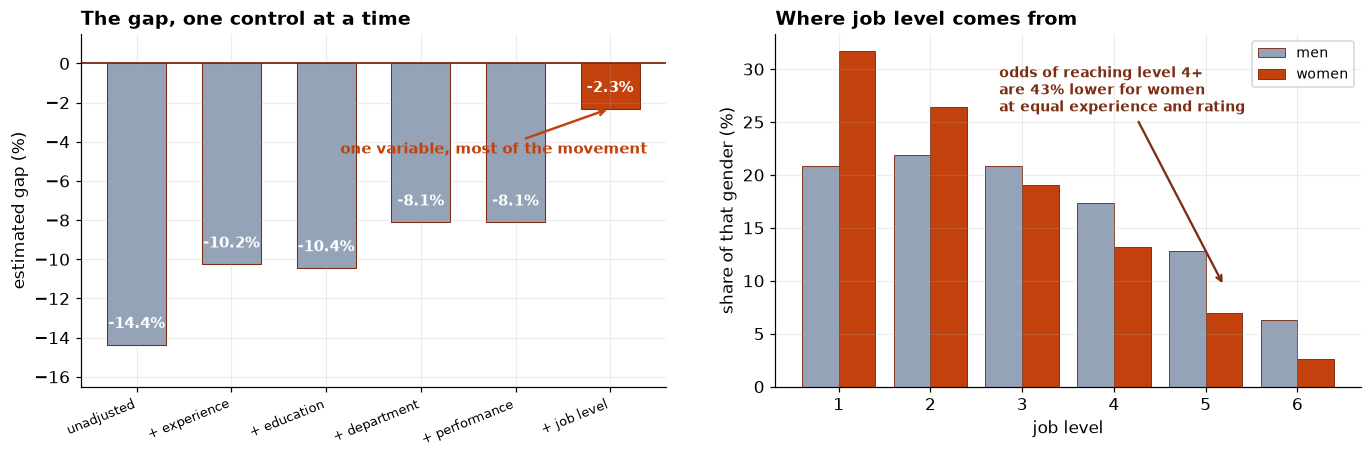

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))

ax = axes[0]
labels = ["unadjusted", "+ experience", "+ education", "+ department", "+ performance", "+ job level"]
gaps = [raw_gap] + [mm.params["female"] for mm in (m1, m2, m3, m4, m5)]
pct = [np.expm1(g)*100 for g in gaps]
cols = [MUT]*5 + [OR]
bars = ax.bar(range(6), pct, color=cols, edgecolor=DK, lw=0.7, width=0.62)
for i, v in enumerate(pct):
    ax.text(i, v + 0.85, f"{v:+.1f}%", ha="center", fontweight="bold", fontsize=9.5, color="white")
ax.axhline(0, color=DK, lw=1.2)
ax.set_xticks(range(6)); ax.set_xticklabels(labels, rotation=22, ha="right", fontsize=8.5)
ax.set_ylabel("estimated gap (%)"); ax.set_ylim(-16.5, 1.5)
ax.annotate("one variable, most of the movement", xy=(5, -2.3), xytext=(2.15, -4.6),
            fontsize=9.5, fontweight="bold", color=OR,
            arrowprops=dict(arrowstyle="->", color=OR, lw=1.6))
ax.set_title("The gap, one control at a time")

ax = axes[1]
lv = np.arange(1, 7)
wf = share["Women %"].values; mn = share["Men %"].values
ax.bar(lv-0.2, mn, 0.4, color=MUT, edgecolor=DK, lw=0.6, label="men")
ax.bar(lv+0.2, wf, 0.4, color=OR, edgecolor=DK, lw=0.6, label="women")
ax.set_xticks(lv); ax.set_xlabel("job level"); ax.set_ylabel("share of that gender (%)")
ax.set_title("Where job level comes from"); ax.legend(fontsize=9)
ax.annotate(f"odds of reaching level 4+\nare {1-odds:.0%} lower for women\nat equal experience and rating",
            xy=(5.2, 9.5), xytext=(2.75, 26), fontsize=9, fontweight="bold", color=DK,
            arrowprops=dict(arrowstyle="->", color=DK, lw=1.5))
plt.tight_layout(); plt.show()

**Left:** the gap under each successive specification. The first four controls between them explain about six points; job level alone explains almost six more. **Right:** why that is. Women are a third of level 1 and a quarter of level 2, and under three percent of level 6, and the promotion model says that is not explained by experience, education, performance or department.

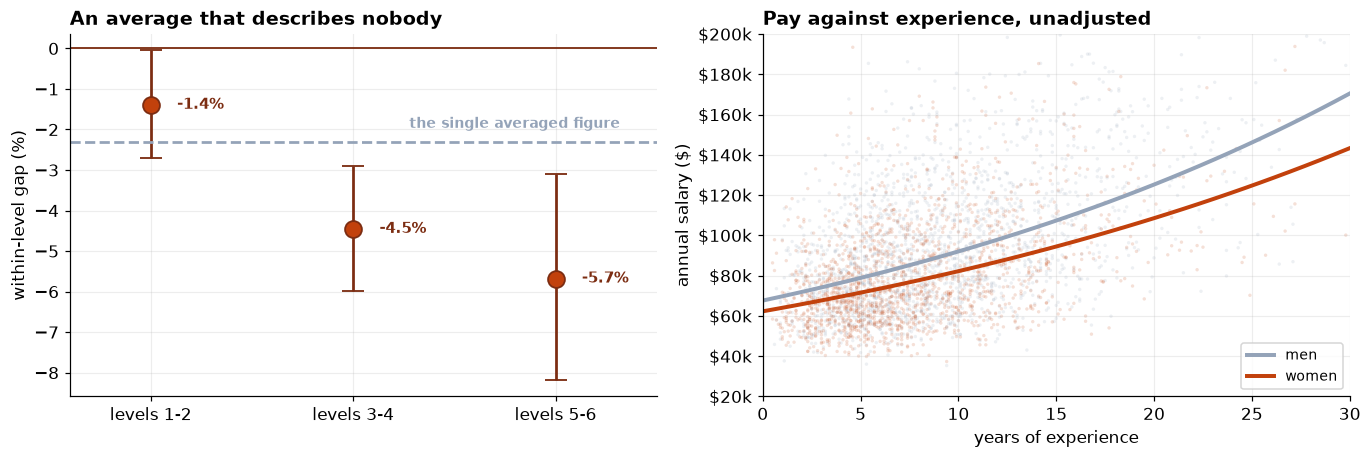

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))

ax = axes[0]
grps = ["1-2", "3-4", "5-6"]
effs, los, his = [], [], []
for grp in grps:
    key = f"female:C(lvgrp)[T.{grp}]"
    e = base + (mi.params[key] if key in mi.params else 0.0)
    se = mi.bse["female"] if key not in mi.params else np.sqrt(
        mi.cov_params().loc["female","female"] + mi.cov_params().loc[key,key]
        + 2*mi.cov_params().loc["female",key])
    effs.append(np.expm1(e)*100); los.append(np.expm1(e-1.96*se)*100); his.append(np.expm1(e+1.96*se)*100)
ax.errorbar(range(3), effs, yerr=[np.array(effs)-np.array(los), np.array(his)-np.array(effs)],
            fmt="o", ms=11, color=OR, ecolor=DK, elinewidth=1.8, capsize=7, mec=DK, mew=1.2)
ax.axhline(0, color=DK, lw=1.2)
ax.axhline(np.expm1(m5.params["female"])*100, color=MUT, lw=1.8, ls="--")
ax.text(2.32, np.expm1(m5.params["female"])*100 + 0.35, "the single averaged figure",
        ha="right", fontsize=9, color=MUT, fontweight="bold")
for i, v in enumerate(effs):
    ax.text(i + 0.13, v, f"{v:+.1f}%", fontsize=10, fontweight="bold", color=DK, va="center")
ax.set_xticks(range(3)); ax.set_xticklabels([f"levels {g}" for g in grps])
ax.set_xlim(-0.4, 2.5); ax.set_ylabel("within-level gap (%)")
ax.set_title("An average that describes nobody")

ax = axes[1]
for g, col, lab in [(0, MUT, "men"), (1, OR, "women")]:
    sub = d[d.female == g]
    ax.scatter(sub.years_experience, sub.annual_salary, s=5, alpha=0.16, color=col, edgecolor="none")
    xs = np.linspace(0, 30, 40)
    b = np.polyfit(sub.years_experience, np.log(sub.annual_salary), 1)
    ax.plot(xs, np.exp(np.polyval(b, xs)), color=col, lw=2.6, label=lab)
ax.set_xlabel("years of experience"); ax.set_ylabel("annual salary ($)")
ax.set_ylim(20000, 200000); ax.set_xlim(0, 30)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))
ax.set_title("Pay against experience, unadjusted"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Left:** the within-level gap by seniority, with intervals, against the single averaged figure as a dashed line. The average is too large for junior grades and less than half the truth at the top. **Right:** the unadjusted relationship. The two fitted lines diverge as experience accumulates, which is the same story the interaction told, seen without any model.

## Step 11 &middot; Ethics, bias, and limits
- **Report both numbers, and say what each one means.** The unadjusted gap describes the workforce. The adjusted gap describes pay-setting within a grade. A report giving only the second is technically accurate and practically misleading.
- **Never control for a company-assigned variable without checking how it is assigned.** Job level took the gap from 8.1 percent to 2.3. That is either the correct adjustment or the erasure of the finding, and only the promotion analysis can tell you which.
- **Say which controls you added and in what order.** Anyone can reach a small number by adding variables. The ladder is the honest presentation, and it is the first thing an opposing expert will reconstruct.
- **A single average can describe nobody.** The gap runs from 1.4 percent at junior grades to 5.7 at senior ones. Reporting 2.3 percent to a senior woman would be wrong by a factor of two and a half.
- **Statistical significance is not the standard of proof here.** A regression coefficient is evidence about a pattern, not a finding about any individual's pay. Individual cases need individual review, and this analysis is a way of deciding where to look.
- **Be careful what a small adjusted gap is used for.** The number is easy to quote as a clean bill of health. What it says is narrower: among people at the same grade, pay is nearly equal. Whether people reach that grade equally is a separate question with a separate and less comfortable answer.
- **Gender here is a recorded binary field.** That is what the HRIS holds. It excludes non-binary employees and anyone whose record is wrong, and the analysis inherits both limitations.

---
**From analysis to report.** The notebook carries the chain: the plan that named two questions, the cleaning and the indicator that kept 69 people in, the unadjusted gap, the specification ladder with the interval at every rung, what collinearity does and does not do, the promotion model that job level was concealing, the interaction that breaks the average apart, and the diagnostics. The written reports turn it into guidance an HR director can act on and a technical account that would survive an opposing expert. Automate the evidence; author the argument.